# Aula — Da análise descritiva à regressão regularizada: o caso da limonada

**Análise Preditiva · 2026-09-01** · material de aula (fora do livro) · dataset: [`ml-zero/dados/limonada/`](https://github.com/GHDaru/machinelearning/tree/main/ml-zero/dados/limonada)

365 dias de uma barraca de limonada: tempo que fez, panfletos distribuídos, preço praticado e copos vendidos. O dado é sintético e limpo de propósito — as armadilhas aparecem sem ruído para escondê-las.

**Roteiro da aula:**

1. **Análise descritiva** de cada campo quantitativo — histograma com boxplot superior, outliers, assimetria, curtose e os cuidados especiais de cada um.
2. **Análise diagnóstica** — correlações entre as variáveis, e a armadilha que mora nelas.
3. **Preparação** dos campos para o modelo — `X`, `y`, divisão treino/teste, padronização sem vazamento.
4. **Regressão linear** — execução, análise dos coeficientes, avaliação (R², MAE, RMSE), resíduos.
5. **Feedback de retorno** — o que o modelo devolve para o problema, e o que ele *não* pode responder.
6. **Ridge e Lasso** — regularização para reduzir parâmetros.
7. **Transformação de variáveis** — quando ajuda, quando é hábito.

Ao final: **prova de 10 questões no Google Forms**.


In [1]:
# --- roda igual na sua máquina e no Colab ------------------------------
# No Colab não há repositório: o CSV é baixado direto do GitHub.
import pathlib, urllib.request

RAW = "https://raw.githubusercontent.com/GHDaru/machinelearning/main/"
CSV = "ml-zero/dados/limonada/limonada.csv"

raiz = pathlib.Path.cwd()
for _ in range(5):
    if (raiz / "ml-zero").is_dir():
        break
    raiz = raiz.parent
else:
    raiz = pathlib.Path.cwd()

caminho = raiz / CSV
if not caminho.exists():
    caminho.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(RAW + CSV, caminho)
print("dados em:", caminho)

dados em: /home/user/machinelearning/ml-zero/dados/limonada/limonada.csv


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*vert.*")

# Paleta da aula: um matiz para o dado, laranja só quando há duas séries a
# contrastar, cinza para o que é contexto. Cor segue papel, não enfeite.
AZUL, LARANJA, CINZA = "#4477AA", "#EE7733", "#BBBBBB"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 10,
})

## 1. O dado

Sete colunas, 365 linhas, nenhum valor faltante. Antes de qualquer gráfico: **que tipo é cada coluna?**

In [3]:
df = pd.read_csv(caminho, parse_dates=["data"])
print(df.shape)
df.head()

(365, 7)


,data,dia_semana,temperatura,precipitacao,panfletos,preco,vendas
0,2017-01-01,Sunday,27.0,2.00,15,0.3,10
1,2017-01-02,Monday,28.9,1.33,15,0.3,13
2,2017-01-03,Tuesday,34.5,1.33,27,0.3,15
3,2017-01-04,Wednesday,44.1,1.05,28,0.3,17
4,2017-01-05,Thursday,42.4,1.00,33,0.3,18


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   data          365 non-null    datetime64[us]
 1   dia_semana    365 non-null    str           
 2   temperatura   365 non-null    float64       
 3   precipitacao  365 non-null    float64       
 4   panfletos     365 non-null    int64         
 5   preco         365 non-null    float64       
 6   vendas        365 non-null    int64         
dtypes: datetime64[us](1), float64(3), int64(2), str(1)
memory usage: 20.1 KB


Separando por papel:

| Coluna | Tipo | Papel |
|---|---|---|
| `data` | temporal | índice — não entra no modelo como número |
| `dia_semana` | categórica | fora do escopo de hoje (viraria *dummies*) |
| `temperatura`, `precipitacao`, `panfletos` | quantitativas contínuas | candidatas a preditoras |
| `preco` | quantitativa **com só dois valores** | guarde isso — vai importar já na descritiva |
| `vendas` | quantitativa (contagem) | **alvo** (`y`) |


## 2. Análise descritiva, campo a campo

O instrumento da aula: **histograma com o boxplot em cima**, compartilhando o eixo x. O boxplot resume (mediana, quartis, cercas); o histograma mostra a forma que o resumo esconde. Junto, imprimimos assimetria (*skewness*), curtose (excesso, referência normal = 0) e a contagem de outliers pela regra do IQR (cerca = quartil ± 1,5×IQR).

In [5]:
QUANTS = ["temperatura", "precipitacao", "panfletos", "preco", "vendas"]

def resumo(s: pd.Series) -> dict:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = s[(s < lo) | (s > hi)]
    return {"n": len(s), "média": s.mean(), "dp": s.std(), "mín": s.min(),
            "Q1": q1, "mediana": s.median(), "Q3": q3, "máx": s.max(),
            "assimetria": s.skew(), "curtose": s.kurt(),
            "cerca inf": lo, "cerca sup": hi, "outliers (IQR)": len(outliers)}

def descritiva(coluna: str, bins=25):
    s = df[coluna]
    fig, (ax_box, ax_hist) = plt.subplots(
        2, 1, sharex=True, figsize=(7, 3.6),
        gridspec_kw={"height_ratios": [1, 4], "hspace": 0.05})
    ax_box.boxplot(s, vert=False, widths=0.55, patch_artist=True,
                   boxprops=dict(facecolor=AZUL, alpha=0.45, edgecolor=AZUL),
                   medianprops=dict(color=LARANJA, linewidth=2),
                   flierprops=dict(marker="o", markersize=4,
                                   markerfacecolor=LARANJA, markeredgecolor="none"))
    ax_box.set(yticks=[], title=coluna)
    ax_box.grid(False)
    ax_hist.hist(s, bins=bins, color=AZUL, edgecolor="white", linewidth=0.6)
    ax_hist.set_ylabel("dias")
    ax_hist.grid(axis="x", visible=False)
    plt.show()
    linha = pd.Series(resumo(s)).to_frame(coluna).T
    return linha.round(3)

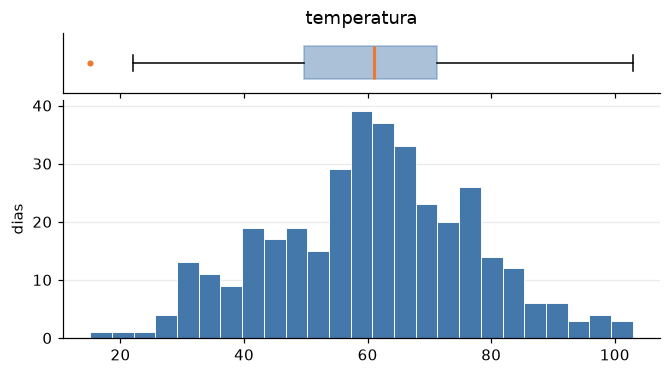

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
temperatura,365.0,60.731,16.196,15.1,49.7,61.1,71.3,102.9,-0.005,-0.22,17.3,103.7,1.0


In [6]:
descritiva("temperatura")

**Temperatura** — distribuição praticamente **simétrica** (assimetria ≈ 0) e um pouco mais "achatada" que a normal (curtose levemente negativa). Um único ponto abaixo da cerca inferior: o dia mais frio do ano. É outlier *estatístico*, não erro de medição — **fica**.

⚠️ **Cuidado especial:** olhe a escala. Mínimo ~15, máximo ~103, média ~61 — isso é **Fahrenheit**, não Celsius. Ler como °C produziria conclusões absurdas ("vendem limonada a 15 °C mais do que a 27 °C?"). Unidade é a primeira coisa que a descritiva confere.

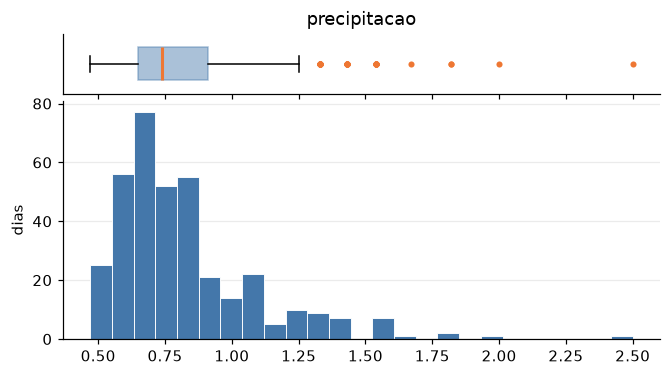

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
precipitacao,365.0,0.827,0.273,0.47,0.65,0.74,0.91,2.5,1.855,5.244,0.26,1.3,28.0


In [7]:
descritiva("precipitacao")

**Precipitação** — aqui a forma muda: **assimetria à direita forte (~1,9)** e **curtose alta (~5)**: cauda longa e pesada. A maioria dos dias tem chuva baixa; alguns poucos têm chuva forte — e a regra do IQR marca ~28 pontos acima da cerca superior.

**Tratamento:** *nenhuma exclusão*. Chuva forte é fenômeno real e é justamente o que derruba venda — apagar esses dias seria apagar a informação. O que a assimetria sugere é outra coisa: esta é a **candidata natural a transformação (log)**, que testaremos na seção 7. Anote e siga.

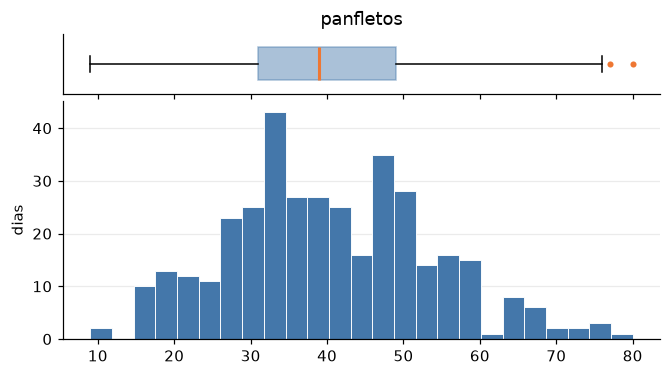

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
panfletos,365.0,40.285,13.179,9.0,31.0,39.0,49.0,80.0,0.306,-0.147,4.0,76.0,2.0


In [8]:
descritiva("panfletos")

**Panfletos** — quase simétrica (assimetria ~0,3), curtose próxima de zero, dois pontos acima da cerca (77 e 80 panfletos). Valores plausíveis para dias de pico — **ficam**. Nenhum tratamento.

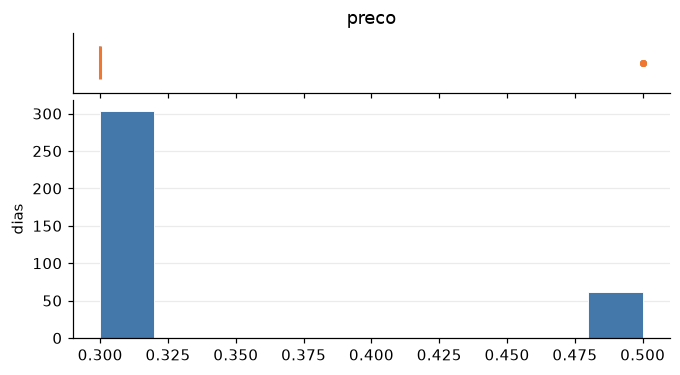

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
preco,365.0,0.334,0.075,0.3,0.3,0.3,0.3,0.5,1.766,1.123,0.3,0.3,62.0


In [9]:
descritiva("preco", bins=10)

**Preço** — e aqui está a **pegadinha da aula**. A regra do IQR marcou **62 outliers**… porque Q1 = Q3 = 0,30: o IQR é **zero**, a cerca colapsa num ponto, e *todo* dia de preço 0,50 vira "outlier".

O diagnóstico correto: `preco` só assume **dois valores** (0,30 e 0,50). Histograma, boxplot, assimetria e curtose pressupõem variável **contínua** — aplicados a uma variável binária, produzem números sem significado. **Tratamento:** tratar `preco` como variável **binária/indicadora**, não como contínua. Remover os "62 outliers" seria deletar julho e agosto do dataset.

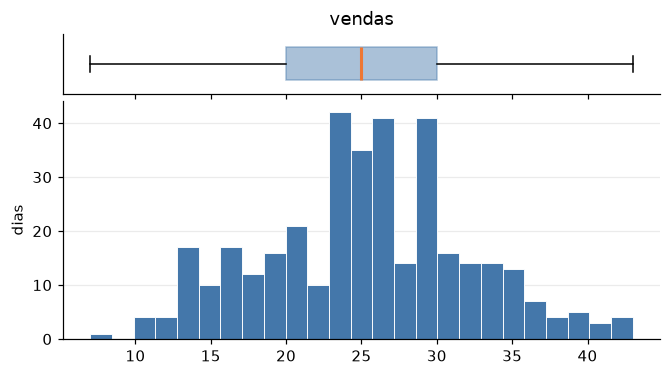

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
vendas,365.0,25.323,6.894,7.0,20.0,25.0,30.0,43.0,0.024,-0.25,5.0,45.0,0.0


In [10]:
descritiva("vendas")

**Vendas (o alvo)** — simétrica, curtose próxima de zero, **zero outliers**. Alvo bem-comportado; nenhuma transformação necessária nele.

### Síntese da descritiva

In [11]:
pd.DataFrame({c: resumo(df[c]) for c in QUANTS}).T.round(3)

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
temperatura,365.0,60.731,16.196,15.10,49.70,61.10,71.30,102.9,-0.005,-0.220,17.30,103.7,1.0
precipitacao,365.0,0.827,0.273,0.47,0.65,0.74,0.91,2.5,1.855,5.244,0.26,1.3,28.0
panfletos,365.0,40.285,13.179,9.00,31.00,39.00,49.00,80.0,0.306,-0.147,4.00,76.0,2.0
preco,365.0,0.334,0.075,0.30,0.30,0.30,0.30,0.5,1.766,1.123,0.30,0.3,62.0
vendas,365.0,25.323,6.894,7.00,20.00,25.00,30.00,43.0,0.024,-0.250,5.00,45.0,0.0


**Cuidados especiais que esta tabela deixa (leve para qualquer dataset):**

1. **Unidade antes de interpretação** — a temperatura está em °F.
2. **Outlier não é sinônimo de erro.** Os de precipitação e panfletos são fenômeno real; excluir seria viés. A decisão é sempre *investigar → decidir*, nunca *deletar por regra*.
3. **A regra do IQR pressupõe variável contínua.** Em variável binária ou quase-discreta ela colapsa (caso do `preco`).
4. **Assimetria forte + cauda pesada** não pede exclusão: pede considerar **transformação** — e medir se ajuda.
5. Tratamento adotado nesta aula: **nenhuma linha removida**; `preco` lido como binária; log em `precipitacao` a testar na seção 7.

## 3. Análise diagnóstica: as correlações

A descritiva olha cada campo sozinho. A diagnóstica pergunta **como eles se movem juntos** — e é onde nasce a primeira conclusão errada.

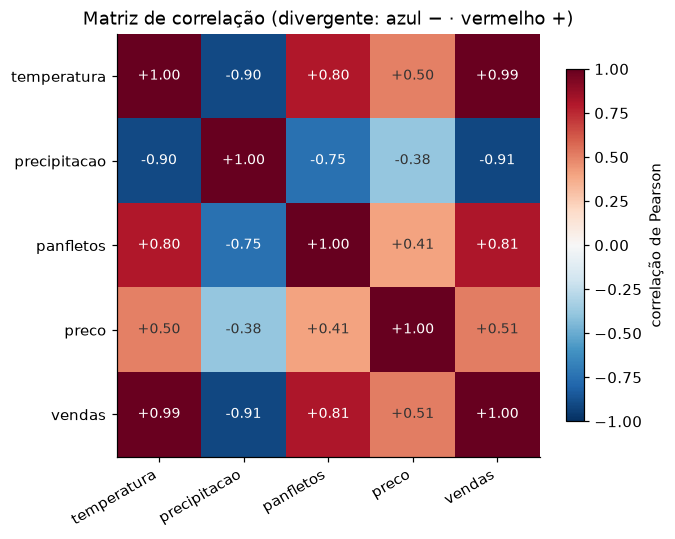

In [12]:
corr = df[QUANTS].corr()

fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(QUANTS)), QUANTS, rotation=30, ha="right")
ax.set_yticks(range(len(QUANTS)), QUANTS)
for i in range(len(QUANTS)):
    for j in range(len(QUANTS)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.6 else "#333333", fontsize=9)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="correlação de Pearson")
ax.set_title("Matriz de correlação (divergente: azul − · vermelho +)")
plt.show()

Três leituras, em ordem de perigo:

1. **Com o alvo:** `temperatura` +0,99 (quase determinística!), `precipitacao` −0,91, `panfletos` +0,81… e **`preco` +0,51**. Lido ingenuamente: *"suba o preço, que a venda sobe"*. Segure essa — é a armadilha central.
2. **Entre preditoras:** `temperatura` × `panfletos` ≈ +0,80 — distribuía-se mais panfleto em dia quente. Isso é **colinearidade**, e vai contaminar a *leitura* dos coeficientes (não a previsão).
3. `temperatura` × `precipitacao` fortemente negativa — as preditoras carregam, todas, o mesmo fator por trás: **a estação**.

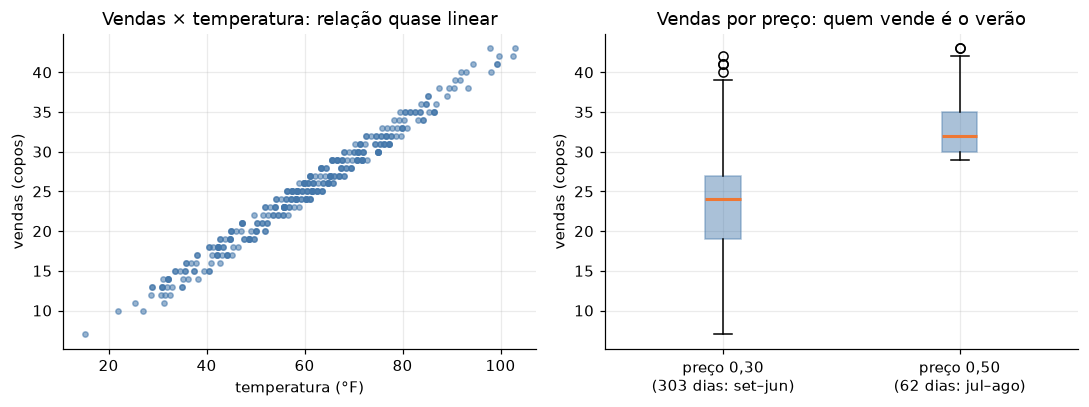

,dias,temperatura_media,vendas_medias,meses
preco,,,,
0.3,303,57.0,23.7,"[1, 2, 3, 4, 5, 6, 9, 10, 11, 12]"
0.5,62,78.8,33.1,"[7, 8]"


In [13]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.8))
a1.scatter(df.temperatura, df.vendas, s=12, color=AZUL, alpha=0.55)
a1.set(xlabel="temperatura (°F)", ylabel="vendas (copos)",
       title="Vendas × temperatura: relação quase linear")

grupos = [df.loc[df.preco == p, "vendas"] for p in (0.3, 0.5)]
a2.boxplot(grupos, tick_labels=["preço 0,30\n(303 dias: set–jun)", "preço 0,50\n(62 dias: jul–ago)"],
           patch_artist=True,
           boxprops=dict(facecolor=AZUL, alpha=0.45, edgecolor=AZUL),
           medianprops=dict(color=LARANJA, linewidth=2))
a2.set(ylabel="vendas (copos)", title="Vendas por preço: quem vende é o verão")
plt.tight_layout(); plt.show()

df.assign(mes=df.data.dt.month).groupby("preco").agg(
    dias=("vendas", "size"), temperatura_media=("temperatura", "mean"),
    vendas_medias=("vendas", "mean"),
    meses=("mes", lambda m: sorted(m.unique()))).round(1)

O preço de 0,50 **só existe em julho e agosto** — os dois meses mais quentes. `preco` não é alavanca aqui: é um **termômetro disfarçado**. A correlação +0,51 mede o verão, não a disposição do freguês a pagar.

> Diagnóstico ≠ recomendação. A correlação diz *o que anda junto*; ela não diz *o que causa o quê* — e nenhum mês do ano tem dois preços, então **não há recorte destes dados** que separe preço de estação. (A história completa está no [capítulo II.2 do livro](https://machinelearning.ghdaru.com.br/ii-2-modelos-lineares.html).)

## 4. Preparação para o modelo: `X`, `y`

Quatro decisões, cada uma com motivo:

1. **`X`** = `temperatura`, `precipitacao`, `panfletos`, `preco` · **`y`** = `vendas`.
2. **Divisão treino/teste (75/25)** com semente fixa — o teste é o "futuro simulado", intocado até a avaliação. (Com dado temporal, a alternativa mais honesta é cortar por data; fica como exercício.)
3. **Padronização** (média 0, desvio 1) — necessária para comparar coeficientes e essencial para Ridge/Lasso, cujas penalidades dependem da escala.
4. O `StandardScaler` **aprende só no treino** e é *aplicado* ao teste. Ajustá-lo no dado inteiro vazaria informação do teste para dentro do treino.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[["temperatura", "precipitacao", "panfletos", "preco"]]
y = df["vendas"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler().fit(X_tr)            # aprende SÓ no treino
X_tr_z = scaler.transform(X_tr)
X_te_z = scaler.transform(X_te)                # o teste é transformado, nunca consultado

print(f"treino: {X_tr.shape} · teste: {X_te.shape}")
pd.DataFrame({"média (treino)": scaler.mean_, "dp (treino)": scaler.scale_},
             index=X.columns).round(3)

treino: (273, 4) · teste: (92, 4)


,média (treino),dp (treino)
temperatura,62.054,15.839
precipitacao,0.803,0.256
panfletos,41.161,13.392
preco,0.335,0.076


## 5. Regressão linear: execução e análise

Com tudo padronizado, cada coeficiente responde: *quantos copos muda a previsão quando este atributo sobe **um desvio-padrão**, mantidos os demais constantes (na equação)*.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

modelo = LinearRegression().fit(X_tr_z, y_tr)

coefs = pd.DataFrame({
    "coef (por dp)": modelo.coef_,
    "coef (unidade original)": modelo.coef_ / scaler.scale_,
}, index=X.columns)
print(f"intercepto: {modelo.intercept_:.3f} copos (previsão no dia 'médio')")
coefs.round(4)

intercepto: 25.883 copos (previsão no dia 'médio')


,coef (por dp),coef (unidade original)
temperatura,5.8364,0.3685
precipitacao,-0.6509,-2.5402
panfletos,0.3021,0.0226
preco,0.1134,1.4891


**Análise dos coeficientes:** a temperatura domina (~5,8 copos por desvio-padrão); a chuva desconta; o panfleto contribui pouco; e o `preco`, que sozinho tinha correlação +0,51, **encolhe para ~0,1 dp** quando a temperatura entra no modelo — quase todo o "efeito" dele era o verão. Repare também no aviso da colinearidade: com preditoras correlacionadas a +0,80, esses números individuais são instáveis por natureza.

### Avaliação nos dois conjuntos

In [16]:
def avalia(nome, m, Xz_tr, Xz_te):
    linhas = []
    for rot, Xz, yy in [("treino", Xz_tr, y_tr), ("teste", Xz_te, y_te)]:
        p = m.predict(Xz)
        linhas.append({"conjunto": rot, "R²": r2_score(yy, p),
                       "MAE (copos)": mean_absolute_error(yy, p),
                       "RMSE (copos)": root_mean_squared_error(yy, p)})
    print(nome)
    return pd.DataFrame(linhas).set_index("conjunto").round(4)

avalia("Regressão linear — 4 atributos", modelo, X_tr_z, X_te_z)

Regressão linear — 4 atributos


,R²,MAE (copos),RMSE (copos)
conjunto,,,
treino,0.9811,0.7963,0.9327
teste,0.9824,0.7805,0.9138


R² ~0,98 **nos dois conjuntos** — treino e teste andam juntos, então não há sobreajuste; o erro típico é de **menos de 1 copo**. Antes de comemorar, os resíduos:

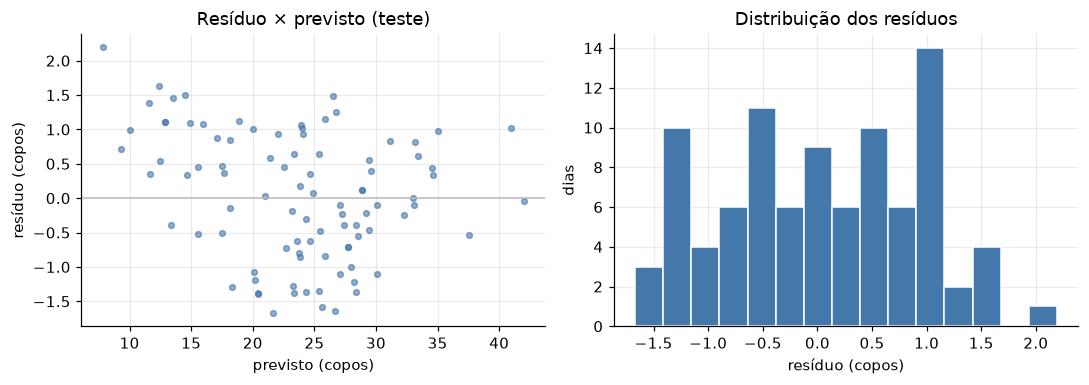

média dos resíduos: +0.038 · dp: 0.918


In [17]:
res_te = y_te - modelo.predict(X_te_z)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
a1.scatter(modelo.predict(X_te_z), res_te, s=14, color=AZUL, alpha=0.6)
a1.axhline(0, color=CINZA, linewidth=1)
a1.set(xlabel="previsto (copos)", ylabel="resíduo (copos)",
       title="Resíduo × previsto (teste)")
a2.hist(res_te, bins=15, color=AZUL, edgecolor="white")
a2.set(xlabel="resíduo (copos)", ylabel="dias", title="Distribuição dos resíduos")
plt.tight_layout(); plt.show()

print(f"média dos resíduos: {res_te.mean():+.3f} · dp: {res_te.std():.3f}")

**Leitura dos resíduos:** centrados em zero, sem funil (variância razoavelmente constante) e sem curva sobrando — a forma linear está adequada. Se aparecesse um **funil** (resíduos abrindo conforme o previsto cresce), o remédio seria transformação do alvo ou pesos; se aparecesse uma **curva**, faltaria termo não linear.

## 6. Feedback de retorno: o que devolver ao problema

O modelo vai bem **na pergunta certa** e falha em silêncio **na errada**:

| Pergunta | O modelo responde? |
|---|---|
| *Quantos copos vendo amanhã, dada a previsão do tempo?* | ✅ Sim — erro típico < 1 copo; serve para estoque e escala de pessoal |
| *Se eu subir o preço, vendo mais?* | ❌ **Não** — o coeficiente de `preco` é positivo por **confundimento** com a estação, e nenhum recorte destes dados separa os dois |
| *Panfletar se paga?* | ⚠️ Duvidoso — o coeficiente equivale a ~50 panfletos por copo extra, e parte disso é o calor do dia (colinearidade) |

**O que reportar de volta:** (a) previsão de demanda está resolvida; (b) para decidir **preço**, é preciso gerar dado novo — variar o preço *dentro do mesmo mês*, em dias comparáveis (um experimento, não mais coleta passiva); (c) coeficiente de variável de controle não se lê como efeito — é a "falácia da Tabela 2" (Westreich & Greenland, 2013).

## 7. Ridge e Lasso: reduzindo parâmetros

Com 4 atributos não há o que reduzir. Para dar trabalho de verdade à regularização, **expandimos** o espaço: quadrados e interações (grau 2) → **14 atributos**. Aí comparamos:

- **Ridge (L2)** — encolhe todos os coeficientes, nenhum vira zero;
- **Lasso (L1)** — encolhe **e zera**: seleção de atributos embutida.

O hiperparâmetro α (força da penalidade) é escolhido por **validação cruzada no treino** — o teste continua intocado.

In [18]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV, LassoCV

pf = PolynomialFeatures(degree=2, include_bias=False).fit(X_tr)
nomes = pf.get_feature_names_out(X.columns)
X_tr2 = pf.transform(X_tr); X_te2 = pf.transform(X_te)

sc2 = StandardScaler().fit(X_tr2)
X_tr2_z = sc2.transform(X_tr2); X_te2_z = sc2.transform(X_te2)

alphas = np.logspace(-3, 2, 60)
lin14 = LinearRegression().fit(X_tr2_z, y_tr)
ridge = RidgeCV(alphas=alphas, cv=5).fit(X_tr2_z, y_tr)
lasso = LassoCV(alphas=alphas, cv=5, max_iter=50_000, random_state=42).fit(X_tr2_z, y_tr)

comp = []
for nome, m in [("Linear (4 atrib.)", modelo), ("Linear (14 atrib.)", lin14),
                ("Ridge (14)", ridge), ("Lasso (14)", lasso)]:
    Xz = X_te_z if m is modelo else X_te2_z
    n_par = int((np.abs(m.coef_) > 1e-6).sum())
    comp.append({"modelo": nome, "R² teste": r2_score(y_te, m.predict(Xz)),
                 "RMSE teste": root_mean_squared_error(y_te, m.predict(Xz)),
                 "parâmetros ≠ 0": n_par,
                 "α": getattr(m, "alpha_", np.nan)})
pd.DataFrame(comp).set_index("modelo").round(4)

,R² teste,RMSE teste,parâmetros ≠ 0,α
modelo,,,,
Linear (4 atrib.),0.9824,0.9138,4,NaN
Linear (14 atrib.),0.9905,0.6711,14,NaN
Ridge (14),0.9900,0.6888,14,0.6261
Lasso (14),0.9906,0.6663,8,0.0070


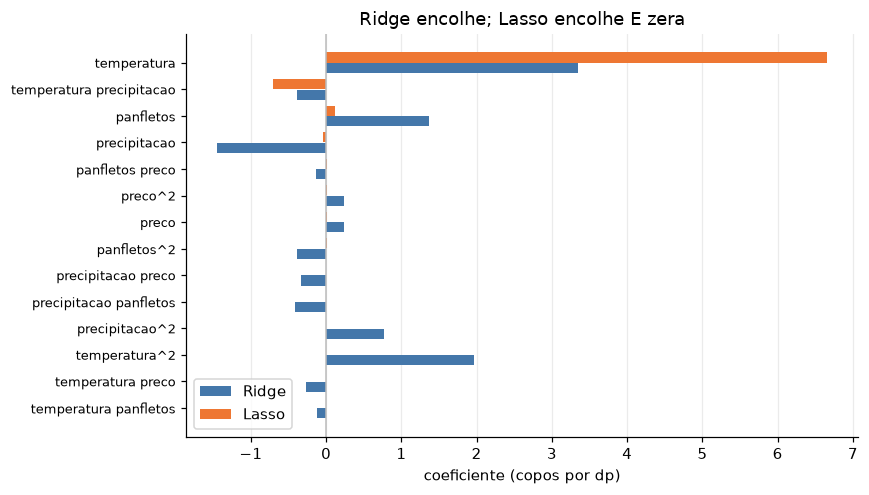

Lasso manteve 8 de 14:
  temperatura                    +6.662
  temperatura precipitacao       -0.712
  panfletos                      +0.121
  precipitacao                   -0.042
  panfletos preco                +0.015
  preco^2                        +0.014
  preco                          +0.013
  panfletos^2                    +0.013


In [19]:
ordem = np.argsort(np.abs(lasso.coef_))[::-1]
pos = np.arange(len(nomes))

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(pos - 0.2, ridge.coef_[ordem][::-1], height=0.38, color=AZUL, label="Ridge")
ax.barh(pos + 0.2, lasso.coef_[ordem][::-1], height=0.38, color=LARANJA, label="Lasso")
ax.set_yticks(pos, [nomes[i] for i in ordem][::-1], fontsize=8.5)
ax.axvline(0, color=CINZA, linewidth=1)
ax.set_xlabel("coeficiente (copos por dp)")
ax.set_title("Ridge encolhe; Lasso encolhe E zera")
ax.legend()
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

mantidos = [(n, round(c, 3)) for n, c in zip(nomes, lasso.coef_) if abs(c) > 1e-6]
print(f"Lasso manteve {len(mantidos)} de {len(nomes)}:")
for n, c in sorted(mantidos, key=lambda t: -abs(t[1])):
    print(f"  {n:30s} {c:+.3f}")

**Leitura de engenharia:** os três modelos de 14 atributos empatam em R² de teste — mas o Lasso chega lá com **8 parâmetros** em vez de 14. Empate de desempenho + menos parâmetros = fique com o mais simples (é o modelo mais barato de manter e de explicar).

E há um achado *interpretável* na seleção: a interação **`temperatura × precipitacao` entra com sinal negativo** — chuva derruba mais venda justamente no dia quente, que era quando havia mais venda a perder. O modelo aditivo simples não tinha como dizer isso.

## 8. Transformação de variáveis: quando ajuda

A seção 2 marcou `precipitacao` (assimetria ~1,9, cauda pesada) como candidata a **log**. Transformar é hipótese — a medida decide.

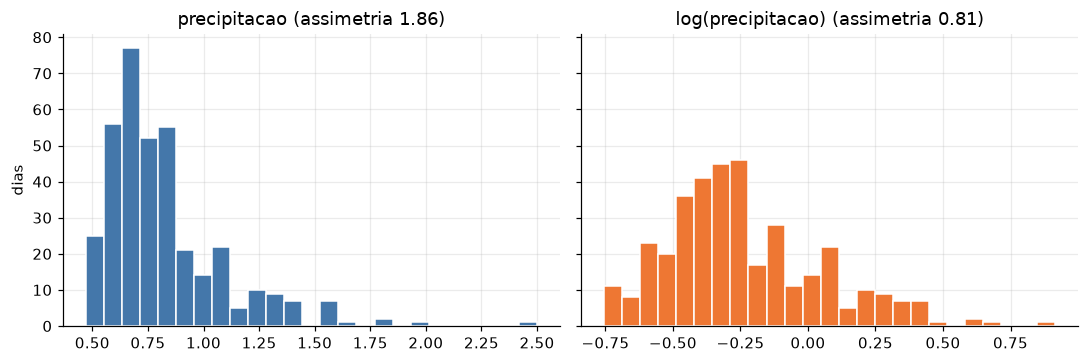

Linear com log(precipitacao)


,R²,MAE (copos),RMSE (copos)
conjunto,,,
treino,0.9850,0.6902,0.8318
teste,0.9839,0.7233,0.8753


In [20]:
X_log = X.copy()
X_log["precipitacao"] = np.log(X_log["precipitacao"])   # min = 0,47 > 0: log direto

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
a1.hist(df.precipitacao, bins=25, color=AZUL, edgecolor="white")
a1.set(title=f"precipitacao (assimetria {df.precipitacao.skew():.2f})", ylabel="dias")
a2.hist(X_log.precipitacao, bins=25, color=LARANJA, edgecolor="white")
a2.set(title=f"log(precipitacao) (assimetria {X_log.precipitacao.skew():.2f})")
plt.tight_layout(); plt.show()

Xl_tr, Xl_te = X_log.loc[X_tr.index], X_log.loc[X_te.index]
scl = StandardScaler().fit(Xl_tr)
m_log = LinearRegression().fit(scl.transform(Xl_tr), y_tr)
avalia("Linear com log(precipitacao)", m_log, scl.transform(Xl_tr), scl.transform(Xl_te))

A assimetria cai de ~1,9 para ~0,8 e o R² de teste **melhora pouco** (~0,982 → ~0,984). Lição dupla:

- a transformação se justifica pelo **resíduo e pela métrica**, não pelo hábito — aqui a relação já era quase linear, então o ganho é marginal;
- quando o ganho vier (e em dados reais de chuva costuma vir), o preço é a **leitura**: o coeficiente passa a ser "copos por dp de *log*-chuva".

## 9. Síntese da aula

1. **Descritiva** é forma + resumo: histograma com boxplot, assimetria, curtose — e a checagem de unidade e de tipo (a regra do IQR quebrou no `preco` binário).
2. **Outlier real não se deleta** — investiga-se; os da chuva eram o próprio fenômeno.
3. **Diagnóstica**: correlação mede o que anda junto — o +0,51 do preço era a estação disfarçada.
4. **Preparação**: padronizador aprende **só no treino**; teste é futuro simulado.
5. **Modelo**: R² ~0,98 sem sobreajuste, resíduos limpos — e coeficientes que **não** são efeitos causais.
6. **Feedback**: o modelo resolve *previsão de demanda*; a decisão de preço exige **dado novo** (variar preço dentro do mês).
7. **Ridge/Lasso**: com atributos expandidos, o Lasso empata em desempenho com 8 de 14 parâmetros — parcimônia de graça.
8. **Transformação**: log domou a assimetria; a métrica decide se fica.

**Agora: a prova de 10 questões no Google Forms.** 📋